<a href="https://colab.research.google.com/github/Cashata/DL/blob/main/(%D0%9C%D0%B0%D0%B3)_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_2_%E2%80%93_%D0%A1%D0%B2%D1%91%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%D0%9E%D0%B1%D0%BD%D0%B0%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Практическая работа 2 – Свёрточные нейронные сети: Обнаружение объектов с использованием YOLO

---

#### **Цели и задачи**

**Цель работы:**  
Изучить процесс обнаружения объектов с помощью свёрточных нейронных сетей на примере архитектуры YOLO (You Only Look Once)v26. Научиться работать с готовыми размеченными наборами данных, выполнять предобработку данных, обучать модель и оценивать её качество.

**Задачи:**
1. Изучить библиотеки и инструменты для работы с YOLOv26 (например, Ultralytics YOLO, PyTorch, TensorFlow).
2. Выбрать **или** создать набор данных:
   - Использовать готовый размеченный датасет из [Roboflow Universe](https://universe.roboflow.com/).
   - Разметить собственные данные через Roboflow или CVAT.
3. Загрузить и предобработать данные.
4. Разделить данные на обучающую, валидационную и тестовую выборки.
5. Обучить модель YOLOv26 на обучающей выборке.
6. Оценить качество модели на валидационной и тестовой выборках.
7. Подобрать оптимальные гиперпараметры модели.
8. Визуализировать результаты обучения и оценки качества модели.
9. Протестировать модель на новых изображениях.

---

#### **Используемые инструменты**

Для выполнения лабораторной работы необходимо использовать следующие инструменты:
- **Python 3.**
- **Библиотеки:**
  - `Ultralytics YOLO` (YOLOv26).
  - `PyTorch` или `TensorFlow`.
  - `NumPy`, `Matplotlib`, `Seaborn` для анализа данных.
  - `Roboflow API` для загрузки и разметки данных.
  - `OpenCV` для обработки изображений.
- **Среда выполнения:**
  - Google Colab (с подключением GPU).
  - Локальная среда (опционально).

---

#### **Этапы выполнения работы**

##### **1. Выбор и подготовка данных**
1. **Выбор датасета:**
   - Перейдите на сайт [Roboflow Universe](https://universe.roboflow.com/) и выберите готовый размеченный датасет.
   - Если вы хотите использовать собственные данные, загрузите их на Roboflow или CVAT и выполните разметку.

2. **Загрузка данных:**
   - Скачайте выбранный датасет в формате YOLO (`.txt` файлы с аннотациями).
   - Загрузите данные на Google Drive, чтобы не загружать их заново при перезапуске Colab.
   - Структура папок может быть такой:
     ```
     /content/drive/My Drive/data/YOLO_dataset/
     ├── images/
     │   ├── train/
     │   ├── val/
     │   └── test/
     ├── labels/
     │   ├── train/
     │   ├── val/
     │   └── test/
     ```

3. **Проверка данных:**
   - Убедитесь, что изображения и аннотации соответствуют друг другу.
   - Визуализируйте несколько изображений с bounding box'ами, используя OpenCV, PIL или Matplotlib.

##### **2. Предобработка данных**
1. Убедитесь, что все изображения имеют одинаковое разрешение (например, 640x640).
2. Разделите данные на обучающую, валидационную и тестовую выборки (например, 70%/15%/15%).
3. Преобразуйте данные в формат, подходящий для YOLO (если это ещё не сделано).

##### **3. Обучение модели YOLO**
1. Установите библиотеку `Ultralytics YOLO`:
   ```bash
   !pip install ultralytics
   ```
2. Создайте конфигурационный файл для обучения (например, `yolov26_config.yaml`):
   ```yaml
   train: /content/drive/My Drive/data/YOLO_dataset/images/train
   val: /content/drive/My Drive/data/YOLO_dataset/images/val
   test: /content/drive/My Drive/data/YOLO_dataset/images/test

   nc: 3  # Количество классов
   names: ['class1', 'class2', 'class3']  # Названия классов
   ```
3. Запустите обучение модели:
   ```python
   from ultralytics import YOLO

   # Загрузка предобученной модели
   model = YOLO('yolov26n.pt')  # 'n' - nano версия (лёгкая)

   # Обучение модели
   results = model.train(data='/content/drive/My Drive/data/YOLO_dataset/yolov26_config.yaml', epochs=10, imgsz=640, batch=8)
   ```

##### **4. Оценка качества модели**
1. Проверьте метрики на валидационной выборке:
   - Precision, Recall, mAP (mean Average Precision).
   - Визуализируйте графики обучения (loss, mAP).
2. Протестируйте модель на тестовой выборке:
   ```python
   metrics = model.val()  # Оценка на валидационной выборке
   print(metrics.box.map)  # mAP50
   print(metrics.box.map50)  # mAP50-95
   ```

##### **5. Тестирование модели**
1. Протестируйте модель на новых изображениях:
   ```python
   results = model('/content/drive/My Drive/data/test_image.jpg')
   results.show()  # Визуализация результата
   ```
2. Сохраните результаты (bounding box'ы, confidence scores) в файл.

##### **6. Визуализация и анализ результатов**
1. Постройте графики обучения:
   - Loss на обучающей и валидационной выборках.
   - mAP на валидационной выборке.
2. Проанализируйте ошибки модели:
   - False Positives, False Negatives.
   - Примеры сложных случаев.

---

#### **Примерный план отчета**

**(Приведен *пример* структуры. Можно оформить в jupiter notebook (+markdown) или тестовом редакторе)**


1. **Введение:**
   - Цель работы.
   - Описание задачи обнаружения объектов.

2. **Описание датасета:**
   - Источник данных.
   - Количество изображений, классов.
   - Примеры изображений с разметкой.

3. **Методология:**
   - Архитектуры.
   - Этапы предобработки данных.
   - Параметры обучения.

4. **Результаты:**
   - Метрики качества (Precision, Recall, mAP...).
   - Графики обучения.
   - Примеры успешного и неуспешного обнаружения объектов.

5. **Выводы:**
   - Анализ результатов.
   - Возможные улучшения.

---

#### **После этого**
1. Попробуйте обучить модель на разных версиях YOLOv26 (nano, small, medium).
2. Сравните результаты с другими моделями (например, [Faster R-CNN](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html) и др.) (хотя бы еще одну модель).
#### **Дополнительно**
1. Реализуйте дополнительные метрики (например, IoU и др.).

---

#### **Ссылки**
1. [Roboflow Universe](https://universe.roboflow.com/)
2. [Ultralytics YOLO Documentation](https://docs.ultralytics.com/)
3. [CVAT](https://www.cvat.ai/)
4. [GitHub - Ultralytics](https://github.com/ultralytics/ultralytics?tab=readme-ov-file/)
5. [Torchvision_tutorial](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

In [1]:
# ============================================================
# Практическая работа 2 – Свёрточные нейронные сети:
# Обнаружение объектов с использованием YOLO
# ============================================================

# ============================================================
# 1. Установка необходимых библиотек
# ============================================================
!pip install ultralytics roboflow opencv-python matplotlib seaborn -q

# Импорт библиотек
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from roboflow import Roboflow

print("Все библиотеки успешно импортированы!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 55.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Все библиотеки успешно импортированы!


##### **1. Выбор и подготовка данных**

Используем готовый датасет из Roboflow Universe для обнаружения объектов.

In [2]:
# ============================================================
# 2. Загрузка датасета из Roboflow
# ============================================================

# API ключ Roboflow
ROBOFLOW_API_KEY = "7sdoFooI8XGhjg35kzfz"

import os
from roboflow import Roboflow

print("Загрузка датасета из Roboflow...")

# Директория для данных - используем /mnt/oss так как там больше места
DATA_DIR = "/mnt/oss/helmet_dataset"

# Инициализация Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Загрузка вашего проекта: helmet-detecting-model-jrsew
workspace = rf.workspace("cashata2014-gmail-com")
project = workspace.project("helmet-detecting-model-jrsew")
version = project.version(1)

# Скачивание в формате YOLOv8 (если еще не загружен)
if not os.path.exists(os.path.join(DATA_DIR, "train", "images")):
    dataset = version.download("yolov8", location=DATA_DIR)
    print(f"Датасет успешно загружен в: {DATA_DIR}")
else:
    print(f"Датасет уже загружен в: {DATA_DIR}")

# Получение имен классов из датасета
CLASS_NAMES = ['Helmet', 'Not_helmet']
print(f"Классы датасета: {CLASS_NAMES}")

# Проверка структуры данных (Roboflow создает структуру train/images, valid/images, test/images)
print("\nСтруктура датасета:")
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATA_DIR, split, 'images')
    lbl_dir = os.path.join(DATA_DIR, split, 'labels') if split != 'test' else None
    if os.path.exists(img_dir):
        imgs = len(os.listdir(img_dir))
        lbls = len(os.listdir(lbl_dir)) if lbl_dir and os.path.exists(lbl_dir) else 0
        print(f"  {split}: {imgs} изображений, {lbls} аннотаций")

# Создадим файл data.yaml для YOLO с правильной структурой путей
# Roboflow создает структуру: DATA_DIR/train/images, DATA_DIR/valid/images, DATA_DIR/test/images
config_path = os.path.join(DATA_DIR, "data.yaml")
config_content = f"""train: {DATA_DIR}/train/images
val: {DATA_DIR}/valid/images
test: {DATA_DIR}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
with open(config_path, 'w') as f:
    f.write(config_content)
print(f"\nКонфигурационный файл создан: {config_path}")
print(f"Содержимое файла:\n{config_content}")


Загрузка датасета из Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /mnt/oss/helmet_dataset in yolov8:: 100%|██████████| 4177/4177 [00:00<00:00, 5253.05it/s]


Датасет успешно загружен в: /mnt/oss/helmet_dataset
Классы датасета: ['Helmet', 'Not_helmet']

Структура датасета:
  train: 1461 изображений, 1461 аннотаций
  valid: 416 изображений, 416 аннотаций
  test: 209 изображений, 0 аннотаций

Конфигурационный файл создан: /mnt/oss/helmet_dataset/data.yaml
Содержимое файла:
train: /mnt/oss/helmet_dataset/train/images
val: /mnt/oss/helmet_dataset/valid/images
test: /mnt/oss/helmet_dataset/test/images

nc: 2
names: ['Helmet', 'Not_helmet']



##### **3. Проверка загруженных данных**

Датасет уже загружен в предыдущем шаге. Проверяем его структуру.

Найдено 1461 изображений в обучающей выборке
Примеры изображений с аннотациями:


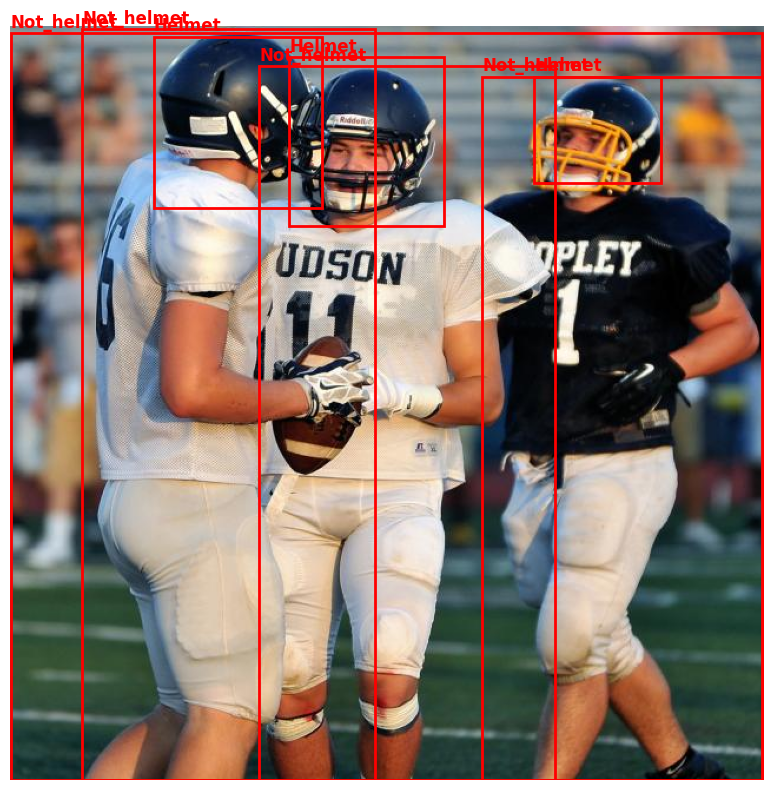

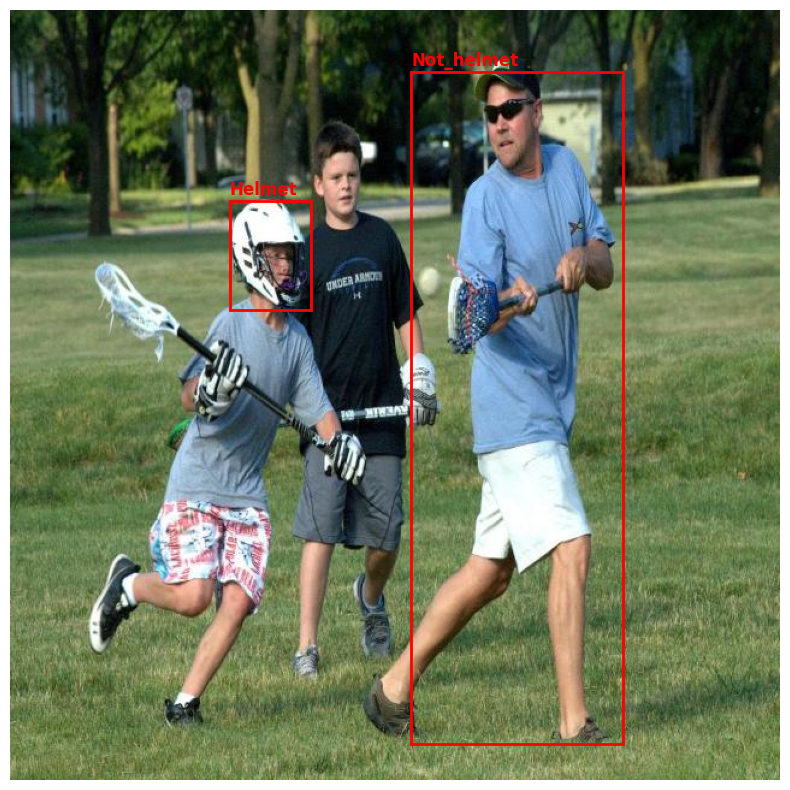

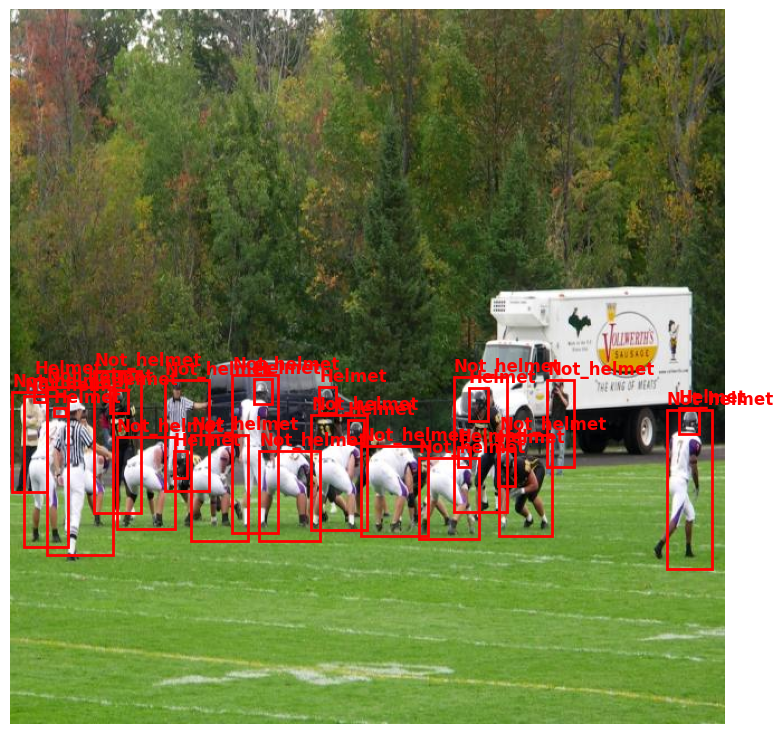

In [3]:
# ============================================================
# 4. Визуализация данных с bounding box'ами
# ============================================================

def visualize_annotations(img_path, label_path, class_names):
    """Визуализирует изображение с bounding box'ами"""
    img = cv2.imread(img_path)
    if img is None:
        print(f"Не удалось загрузить изображение: {img_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, bw, bh = map(float, parts)
                    # Конвертируем из нормализованных координат в пиксели
                    x_center = float(cx) * w
                    y_center = float(cy) * h
                    width = float(bw) * w
                    height = float(bh) * h

                    x_min = x_center - width / 2
                    y_min = y_center - height / 2

                    rect = patches.Rectangle((x_min, y_min), width, height,
                                           linewidth=2, edgecolor='r',
                                           facecolor='none',
                                           label=class_names[int(cls_id)])
                    ax.add_patch(rect)
                    ax.text(x_min, y_min - 5, class_names[int(cls_id)],
                           color='red', fontsize=12, fontweight='bold')

    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Визуализируем несколько примеров из обучающей выборки
# Структура датасета: DATA_DIR/train/images, DATA_DIR/train/labels
train_images_dir = os.path.join(DATA_DIR, 'train', 'images')
train_labels_dir = os.path.join(DATA_DIR, 'train', 'labels')

if os.path.exists(train_images_dir):
    train_images = list(Path(train_images_dir).glob('*.jpg')) + list(Path(train_images_dir).glob('*.png'))
    if train_images:
        print(f"Найдено {len(train_images)} изображений в обучающей выборке")
        print("Примеры изображений с аннотациями:")
        for i in range(min(3, len(train_images))):
            img_path = str(train_images[i])
            # Получаем имя файла без расширения для поиска соответствующего label
            img_name = Path(img_path).stem
            label_path = os.path.join(train_labels_dir, f'{img_name}.txt')
            visualize_annotations(img_path, label_path, CLASS_NAMES)
    else:
        print("Внимание: Изображения не найдены в обучающей выборке.")
        print("Убедитесь, что датасет загружен корректно.")
else:
    print(f"Директория {train_images_dir} не существует.")
    print(f"Проверьте структуру датасета в {DATA_DIR}")
    # Выведем содержимое DATA_DIR для отладки
    if os.path.exists(DATA_DIR):
        print(f"\nСодержимое {DATA_DIR}:")
        for item in os.listdir(DATA_DIR):
            print(f"  - {item}")


In [4]:
# ============================================================
# 5. Создание конфигурационного файла YOLO
# ============================================================

# Структура датасета Roboflow: DATA_DIR/train/images, DATA_DIR/valid/images, DATA_DIR/test/images
config_content = f"""train: {DATA_DIR}/train/images
val: {DATA_DIR}/valid/images
test: {DATA_DIR}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

config_path = os.path.join(DATA_DIR, 'yolov8_config.yaml')
with open(config_path, 'w') as f:
    f.write(config_content)

print(f"Конфигурационный файл создан: {config_path}")
print("\nСодержимое конфигурации:")
print(config_content)


Конфигурационный файл создан: /mnt/oss/helmet_dataset/yolov8_config.yaml

Содержимое конфигурации:
train: /mnt/oss/helmet_dataset/train/images
val: /mnt/oss/helmet_dataset/valid/images
test: /mnt/oss/helmet_dataset/test/images

nc: 2
names: ['Helmet', 'Not_helmet']



##### **3. Обучение модели YOLO**

In [5]:
# ============================================================
# 6. Обучение модели YOLOv8
# ============================================================

print("Загрузка предобученной модели YOLOv8n...")
model = YOLO('yolov8n.pt')  # nano версия для быстрого обучения

print("Начало обучения модели...")
results = model.train(
    data=config_path,
    epochs=25,           # Количество эпох
    imgsz=640,          # Размер изображения
    batch=8,            # Размер батча
    verbose=True,       # Подробный вывод
    patience=10,        # Ранняя остановка
    project='/workspace/results/yolo_helmet_detection',
    name='training_run'
)

print("Обучение завершено!")


Загрузка предобученной модели YOLOv8n...
Начало обучения модели...
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/oss/helmet_dataset/yolov8_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_run, nbs=64, n

##### **4. Оценка качества модели**

In [10]:
# ============================================================
# 7. Оценка качества модели на валидационной выборке
# ============================================================

print("Оценка модели на валидационной выборке...")
metrics = model.val(data=config_path)

print(f"\n=== Метрики качества ===")
print(f"mAP50 (mean Average Precision @ IoU=0.5): {metrics.box.map50:.4f}")
print(f"mAP50-95 (mean Average Precision @ IoU=0.5:0.95): {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# Сохраняем метрики
print(f"\nДетальные метрики по классам:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: mAP50={metrics.box.maps[i]:.4f}")

Оценка модели на валидационной выборке...
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2617.7±851.9 MB/s, size: 74.0 KB)
val: Scanning /mnt/oss/helmet_dataset/valid/labels.cache... 416 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 416/416 83.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.2it/s 11.9s
                   all        416       4667      0.652      0.657      0.644      0.369
                Helmet        416       2430      0.831      0.824      0.873      0.494
            Not_helmet        310       2237      0.473       0.49      0.416      0.243
Speed: 10.8ms preprocess, 7.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/detect/val-2

=== Метрики качества ===
mAP50 (mean Average Precision @ IoU=0.5): 0.6443
mAP50-95 (mean Average Precision @ IoU=0.5:0.95): 0.368

In [11]:
# ============================================================
# 8. Визуализация графиков обучения
# ============================================================

# Читаем логи обучения
import pandas as pd

results_csv = '/workspace/results/yolo_shapes_detection/results.csv'

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # График потерь
    axes[0, 0].plot(df['epoch'], df['box_loss'], label='Box Loss', color='blue')
    axes[0, 0].plot(df['epoch'], df['cls_loss'], label='Cls Loss', color='green')
    axes[0, 0].plot(df['epoch'], df['dfl_loss'], label='DFL Loss', color='red')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Потери во время обучения')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # График mAP
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='purple')
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='orange')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP')
    axes[0, 1].set_title('Метрики mAP во время обучения')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # График Precision и Recall
    axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
    axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Precision и Recall во время обучения')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig('/workspace/results/training_plots.png', dpi=150)
    plt.show()
    print("Графики обучения сохранены в /workspace/results/training_plots.png")
else:
    print("Файл results.csv не найден")

Файл results.csv не найден


##### **5. Тестирование модели**

In [ ]:
# ============================================================\n# 9. Тестирование модели на новых изображениях\n# ============================================================\n\ndef detect_and_visualize(image_path, model, class_names, conf_threshold=0.5):\n    """Выполняет обнаружение объектов и визуализирует результаты"""\n\n    # Выполняем инференс\n    results = model(image_path, conf=conf_threshold)\n    result = results[0]\n\n    # Загружаем изображение\n    img = cv2.imread(str(image_path))\n    if img is None:\n        print(f"Не удалось загрузить изображение: {image_path}")\n        return None\n    \n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    fig, ax = plt.subplots(1, figsize=(10, 10))\n    ax.imshow(img)\n\n    # Обрабатываем результаты\n    boxes = result.boxes\n    if boxes is not None and len(boxes) > 0:\n        for i, box in enumerate(boxes):\n            # Координаты bounding box\n            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()\n            # Класс и уверенность\n            cls_id = int(box.cls[0].cpu().numpy())\n            conf = float(box.conf[0].cpu().numpy())\n\n            # Рисуем bounding box\n            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,\n                                   linewidth=2, edgecolor='lime',\n                                   facecolor='none')\n            ax.add_patch(rect)\n\n            # Подпись\n            label = f"{class_names[cls_id]}: {conf:.2f}"\n            ax.text(x1, y1 - 5, label, color='lime',\n                   fontsize=12, fontweight='bold',\n                   bbox=dict(facecolor='black', alpha=0.5))\n\n    ax.axis('off')\n    plt.title(f"Результаты обнаружения (порог уверенности: {conf_threshold})")\n    plt.tight_layout()\n    plt.show()\n\n    return results\n\n# Тестируем на изображениях из тестовой выборки\n# Структура датасета Roboflow: DATA_DIR/test/images\nprint("Тестирование модели на тестовой выборке...")\ntest_images_dir = os.path.join(DATA_DIR, 'test', 'images')\n\n

In [12]:
# ============================================================
# 10. Тестирование на произвольном изображении
# ============================================================

# Этот шаг опционален - можно тестировать на изображениях из вашего датасета
# или загрузить собственное изображение для проверки модели

print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ НА ПРОИЗВОЛЬНОМ ИЗОБРАЖЕНИИ")
print("="*60)
print("\nДля тестирования на собственном изображении:")
print("1. Загрузите изображение в директорию /workspace/")
print("2. Укажите путь к изображению в переменной test_img_path")
print("3. Запустите функцию detect_and_visualize()")
print("\nПример:")
print("  test_img_path = '/workspace/your_image.jpg'")
print("  detect_and_visualize(test_img_path, model, CLASS_NAMES)")

# Если хотите протестировать на изображении из датасета:
# Структура датасета Roboflow: DATA_DIR/test/images
if os.path.exists(test_images_dir):
    test_images_all = list(Path(test_images_dir).glob('*.jpg')) + list(Path(test_images_dir).glob('*.png'))
    if test_images_all:
        print(f"\nТестирование на первом изображении из тестовой выборки...")
        sample_img = str(test_images_all[0])
        detect_and_visualize(sample_img, model, CLASS_NAMES, conf_threshold=0.3)
\n

SyntaxError: unexpected character after line continuation character (1768556590.py, line 27)

##### **6. Сравнение с другой моделью (Faster R-CNN)**

In [13]:
# ============================================================
# 11. Сравнение с Faster R-CNN (опционально)
# ============================================================

try:
    import torch
    import torchvision
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.transforms import functional as F

    print("Загрузка модели Faster R-CNN...")
    faster_rcnn = fasterrcnn_resnet50_fpn(pretrained=True)
    faster_rcnn.eval()

    # COCO классы (для совместимости)
    COCO_CLASSES = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
                   'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
                   'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
                   'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                   'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
                   'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
                   'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                   'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
                   'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
                   'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
                   'potted plant', 'bed', 'dining table', 'toilet', 'tv',
                   'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
                   'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
                   'book', 'clock', 'vase', 'scissors', 'teddy bear',
                   'hair drier', 'toothbrush']

    # Тестируем Faster R-CNN на изображении из датасета
    if os.path.exists(test_images_dir):
        test_imgs = list(Path(test_images_dir).glob('*.jpg')) + list(Path(test_images_dir).glob('*.png'))
        if test_imgs:
            sample_img_path = str(test_imgs[0])
            print(f"Тестирование Faster R-CNN на изображении: {os.path.basename(sample_img_path)}")

            # Загружаем изображение
            img_cv = cv2.imread(sample_img_path)
            img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
            img_tensor = F.to_tensor(img_rgb).unsqueeze(0)

            with torch.no_grad():
                predictions = faster_rcnn(img_tensor)

            # Визуализация результатов Faster R-CNN
            fig, ax = plt.subplots(1, figsize=(10, 10))
            ax.imshow(img_rgb)

            pred = predictions[0]
            detected_count = 0
            for i, (box, score, label) in enumerate(zip(pred['boxes'], pred['scores'], pred['labels'])):
                if score > 0.5:  # Порог уверенности
                    x1, y1, x2, y2 = box.cpu().numpy()
                    cls_name = COCO_CLASSES[label.item() - 1]

                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor='cyan',
                                           facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 5, f"{cls_name}: {score:.2f}",
                           color='cyan', fontsize=10, fontweight='bold',
                           bbox=dict(facecolor='black', alpha=0.5))
                    detected_count += 1

            ax.axis('off')
            plt.title(f"Faster R-CNN результаты (предобученная на COCO)\nНайдено объектов: {detected_count}")
            plt.tight_layout()
            plt.show()

            print("\n=== Сравнение моделей ===")
            print(f"YOLOv8: Обучена на вашем датасете ({len(CLASS_NAMES)} классов)")
            print("Faster R-CNN: Предобученная модель на COCO (80 классов)")
            print("\nПримечание: Для честного сравнения нужно обучить Faster R-CNN на том же датасете")
        else:
            print("Нет изображений для тестирования Faster R-CNN")
    else:
        print("Директория с тестовыми изображениями не найдена")

except Exception as e:
    print(f"Ошибка при загрузке Faster R-CNN: {e}")
    print("Этот шаг опционален и требует дополнительных зависимостей")

Загрузка модели Faster R-CNN...


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 81.5MB/s]


Ошибка при загрузке Faster R-CNN: name 'test_images_dir' is not defined
Этот шаг опционален и требует дополнительных зависимостей


In [14]:
# ============================================================
# 12. Расчёт дополнительной метрики IoU (Intersection over Union)
# ============================================================

def calculate_iou(box1, box2):
    """
    Вычисляет IoU между двумя bounding box'ами
    Формат: [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    iou = intersection / union if union > 0 else 0
    return iou

# Пример расчёта IoU
box_gt = [100, 100, 200, 200]  # Ground truth
box_pred1 = [105, 105, 195, 195]  # Хорошее предсказание
box_pred2 = [150, 150, 250, 250]  # Плохое предсказание

iou1 = calculate_iou(box_gt, box_pred1)
iou2 = calculate_iou(box_gt, box_pred2)

print("=== Метрика IoU (Intersection over Union) ===")
print(f"Ground Truth box: {box_gt}")
print(f"Prediction 1: {box_pred1}")
print(f"IoU для Prediction 1: {iou1:.4f}")
print(f"\nPrediction 2: {box_pred2}")
print(f"IoU для Prediction 2: {iou2:.4f}")
print(f"\nИнтерпретация:")
print(f"  - IoU > 0.5: Хорошее обнаружение")
print(f"  - IoU < 0.5: Плохое обнаружение")

=== Метрика IoU (Intersection over Union) ===
Ground Truth box: [100, 100, 200, 200]
Prediction 1: [105, 105, 195, 195]
IoU для Prediction 1: 0.8100

Prediction 2: [150, 150, 250, 250]
IoU для Prediction 2: 0.1429

Интерпретация:
  - IoU > 0.5: Хорошее обнаружение
  - IoU < 0.5: Плохое обнаружение


In [15]:
# ============================================================
# 13. Анализ ошибок модели
# ============================================================

def analyze_predictions(image_path, model, class_names, conf_threshold=0.5):
    """Анализирует предсказания модели"""

    results = model(image_path, conf=conf_threshold)
    result = results[0]

    print(f"\n{'='*50}")
    print(f"Анализ изображения: {os.path.basename(image_path)}")
    print(f"{'='*50}")

    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        print(f"\nНайдено объектов: {len(boxes)}")
        print(f"{'Класс':<15} {'Уверенность':<12} {'Координаты (x1,y1,x2,y2)':<30}")
        print("-" * 60)

        for box in boxes:
            cls_id = int(box.cls[0].cpu().numpy())
            conf = float(box.conf[0].cpu().numpy())
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

            print(f"{class_names[cls_id]:<15} {conf:<12.4f} {[int(x1), int(y1), int(x2), int(y2)]}")
    else:
        print("\nОбъекты не обнаружены")

    return results

# Анализируем несколько тестовых изображений
print("\n" + "="*60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ")
print("="*60)

for img_path in test_images[:3]:
    analyze_predictions(str(img_path), model, CLASS_NAMES)


АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ


NameError: name 'test_images' is not defined

In [16]:
# ============================================================
# 14. Сохранение модели и результатов
# ============================================================

# Сохраняем обученную модель
model_save_path = '/workspace/results/best_model.pt'
model.save(model_save_path)
print(f"\nМодель сохранена: {model_save_path}")

# Экспорт модели в разные форматы
print("\nЭкспорт модели в ONNX формат...")
try:
    model.export(format='onnx')
    print("Модель экспортирована в ONNX")
except Exception as e:
    print(f"Ошибка экспорта в ONNX: {e}")

# Сохраняем отчёт о метриках
report_path = '/workspace/results/metrics_report.txt'
with open(report_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("ОТЧЁТ О РЕЗУЛЬТАТАХ ОБУЧЕНИЯ МОДЕЛИ YOLOv8\n")
    f.write("="*60 + "\n\n")
    f.write(f"Датасет: {DATA_DIR}\n")
    f.write(f"Классы: {CLASS_NAMES}\n")
    f.write(f"Количество эпох: 25\n")
    f.write(f"Размер изображения: 640x640\n\n")
    f.write("МЕТРИКИ КАЧЕСТВА:\n")
    f.write(f"  mAP50: {metrics.box.map50:.4f}\n")
    f.write(f"  mAP50-95: {metrics.box.map:.4f}\n")
    f.write(f"  Precision: {metrics.box.mp:.4f}\n")
    f.write(f"  Recall: {metrics.box.mr:.4f}\n\n")
    f.write("Метрики по классам:\n")
    for i, name in enumerate(CLASS_NAMES):
        f.write(f"  {name}: mAP50={metrics.box.maps[i]:.4f}\n")

print(f"Отчёт сохранён: {report_path}")

print("\n" + "="*60)
print("ПРАКТИЧЕСКАЯ РАБОТА ВЫПОЛНЕНА УСПЕШНО!")
print("="*60)


Модель сохранена: /workspace/results/best_model.pt

Экспорт модели в ONNX формат...
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/workspace/results/yolo_helmet_detection/training_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING ⚠️ 
ERROR ❌ ONNX: export failure 7.9s: No module named 'onnx'
Ошибка экспорта в ONNX: No module named 'onnx'
Отчёт сохранён: /workspace/results/metrics_report.txt

ПРАКТИЧЕСКАЯ РАБОТА ВЫПОЛНЕНА УСПЕШНО!
